# MACHINE_LEARNING_II_IDL02 — Clasificación de rayos X con CNN (PyTorch)

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) (Kaggle)

**Clases:** `NORMAL` y `PNEUMONIA`

**Flujo:** descarga de datos → EDA → CNN → validación → random search → evaluación en test

> En **Colab**: *Runtime → Change runtime type → T4 GPU*.  
> En **PC local**: perfil CPU automático (menos épocas).


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 131MB/s]

Contenido principal:
['val', 'train', 'chest_xray', '__MACOSX', 'test']

Contenido TRAIN:
['PNEUMONIA', 'NORMAL']

Contenido TEST:
['PNEUMONIA', 'NORMAL']

Contenido VAL:
['PNEUMONIA', 'NORMAL']

CANTIDAD DE IMÁGENES
NORMAL: 1341
PNEUMONIA: 3875


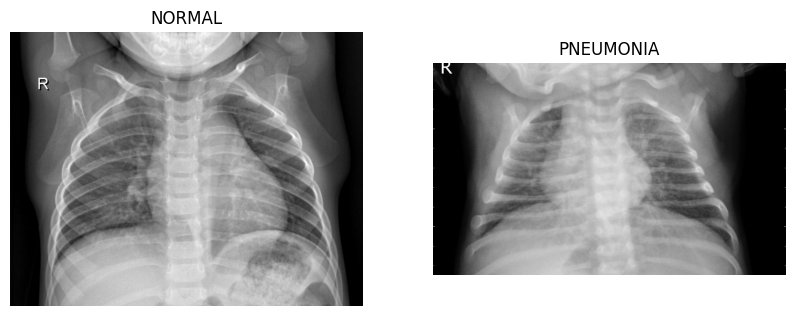

In [2]:
# =========================================================
# INSTALAR KAGGLE
# =========================================================

!pip install -q kaggle


# =========================================================
# CONFIGURAR TOKEN DIRECTAMENTE
# =========================================================

import os
from google.colab import userdata

TOKEN = userdata.get('MI_TOKEN')

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write(TOKEN)

os.chmod("/root/.kaggle/access_token", 0o600)


# =========================================================
# DESCARGAR DATASET
# =========================================================

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


# =========================================================
# DESCOMPRIMIR
# =========================================================

!unzip -q chest-xray-pneumonia.zip


# =========================================================
# VERIFICAR ESTRUCTURA
# =========================================================

import os

print("Contenido principal:")
print(os.listdir("chest_xray"))

print("\nContenido TRAIN:")
print(os.listdir("chest_xray/train"))

print("\nContenido TEST:")
print(os.listdir("chest_xray/test"))

print("\nContenido VAL:")
print(os.listdir("chest_xray/val"))


# =========================================================
# CONTAR IMÁGENES
# =========================================================

train_normal = len(os.listdir("chest_xray/train/NORMAL"))
train_pneumonia = len(os.listdir("chest_xray/train/PNEUMONIA"))

print("\n==============================")
print("CANTIDAD DE IMÁGENES")
print("==============================")

print(f"NORMAL: {train_normal}")
print(f"PNEUMONIA: {train_pneumonia}")


# =========================================================
# MOSTRAR IMÁGENES
# =========================================================

import matplotlib.pyplot as plt
from PIL import Image
import random

normal_path = "chest_xray/train/NORMAL"
pneumonia_path = "chest_xray/train/PNEUMONIA"

normal_img = random.choice(os.listdir(normal_path))
pneumonia_img = random.choice(os.listdir(pneumonia_path))

img1 = Image.open(os.path.join(normal_path, normal_img))
img2 = Image.open(os.path.join(pneumonia_path, pneumonia_img))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

## 1. Importaciones y dispositivo


In [3]:
import itertools
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")


Dispositivo: cuda
GPU: Tesla T4
PyTorch: 2.10.0+cu128


## 2. Configuración


In [4]:
import sys

DATA_ROOT = Path("/content/chest_xray") if "google.colab" in sys.modules else Path("chest_xray")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASSES = ["NORMAL", "PNEUMONIA"]
IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

RUN_PROFILE = "auto"
_profile = RUN_PROFILE if RUN_PROFILE != "auto" else ("gpu" if torch.cuda.is_available() else "cpu")
VAL_RATIO = 0.2

if _profile == "gpu":
    IMG_SIZE, BATCH_SIZE, NUM_WORKERS = 128, 64, 2
    USE_AMP = True
    N_RANDOM_TRIALS, HP_TRIAL_EPOCHS = 1, [10]
    HP_TRIAL_PATIENCE, BASELINE_EPOCHS, FINAL_MAX_EPOCHS = 3, 10, 15
else:
    IMG_SIZE, BATCH_SIZE, NUM_WORKERS = 128, 32, 0
    USE_AMP = False
    N_RANDOM_TRIALS, HP_TRIAL_EPOCHS = 1, [2]
    HP_TRIAL_PATIENCE, BASELINE_EPOCHS, FINAL_MAX_EPOCHS = 1, 5, 8

print(f"Perfil: {_profile.upper()} | batch={BATCH_SIZE} | AMP={USE_AMP}")
print(f"Trials={N_RANDOM_TRIALS} | épocas/trial={HP_TRIAL_EPOCHS}")


def list_images(folder: Path) -> list:
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


assert TRAIN_DIR.exists(), f"No se encuentra {TRAIN_DIR}"
assert TEST_DIR.exists(), f"No se encuentra {TEST_DIR}"


Perfil: GPU | batch=64 | AMP=True
Trials=1 | épocas/trial=[10]


## 3. EDA


TRAIN: {'NORMAL': 1341, 'PNEUMONIA': 3875} | Total: 5216
TEST:  {'NORMAL': 234, 'PNEUMONIA': 390} | Total: 624


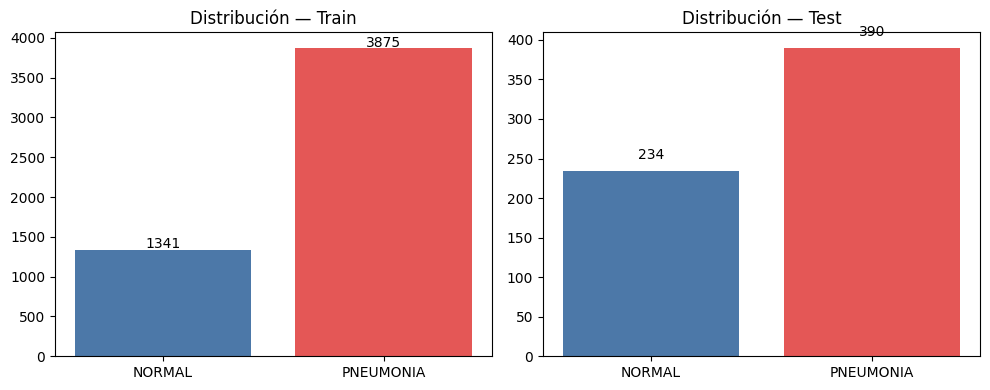

In [5]:
def count_images(root: Path) -> dict:
    return {cls: len(list_images(root / cls)) for cls in CLASSES}

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)
print("TRAIN:", train_counts, "| Total:", sum(train_counts.values()))
print("TEST: ", test_counts, "| Total:", sum(test_counts.values()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes, [train_counts, test_counts], ["Train", "Test"]):
    labels, values = list(counts.keys()), list(counts.values())
    bars = ax.bar(labels, values, color=["#4C78A8", "#E45756"])
    ax.set_title(f"Distribución — {title}")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 15, str(v), ha="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_class_distribution.png", dpi=120)
plt.show()


## 4. Preprocesamiento


In [6]:
def compute_mean_std(loader):
    ch_sum, ch_sq, n = 0, 0, 0
    for data, _ in loader:
        ch_sum += data.mean(dim=[0, 2, 3])
        ch_sq += (data ** 2).mean(dim=[0, 2, 3])
        n += 1
    mean = ch_sum / n
    std = (ch_sq / n - mean ** 2).sqrt()
    return mean.tolist(), std.tolist()


base_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
tmp_ds = datasets.ImageFolder(TRAIN_DIR, transform=base_tf)
tmp_loader = DataLoader(tmp_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
MEAN, STD = compute_mean_std(tmp_loader)
print("Mean/Std:", MEAN, STD)


def get_transforms(augment=False):
    ops = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ]
    if augment:
        ops.append(transforms.RandomHorizontalFlip(p=0.5))
    ops.extend([transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)])
    return transforms.Compose(ops)

full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=get_transforms(augment=True))
test_ds = datasets.ImageFolder(TEST_DIR, transform=get_transforms(augment=False))


Mean/Std: [0.4823058545589447] [0.2350914180278778]


## 5. División train / validación


In [7]:
def stratified_indices(dataset, val_ratio=0.2, seed=42):
    labels = [dataset.samples[i][1] for i in range(len(dataset))]
    by_class = {}
    for i, y in enumerate(labels):
        by_class.setdefault(y, []).append(i)
    rng = random.Random(seed)
    train_idx, val_idx = [], []
    for idxs in by_class.values():
        rng.shuffle(idxs)
        n_val = int(len(idxs) * val_ratio)
        val_idx.extend(idxs[:n_val])
        train_idx.extend(idxs[n_val:])
    return train_idx, val_idx


train_idx, val_idx = stratified_indices(full_train_ds, VAL_RATIO, SEED)
train_ds = Subset(full_train_ds, train_idx)
val_ds = Subset(datasets.ImageFolder(TRAIN_DIR, transform=get_transforms(augment=False)), val_idx)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


def make_loaders(bs):
    kw = dict(num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"))
    if NUM_WORKERS > 0:
        kw["persistent_workers"] = True
        kw["prefetch_factor"] = 2
    return (
        DataLoader(train_ds, batch_size=bs, shuffle=True, **kw),
        DataLoader(val_ds, batch_size=bs, shuffle=False, **kw),
        DataLoader(test_ds, batch_size=bs, shuffle=False, **kw),
    )

train_loader, val_loader, test_loader = make_loaders(BATCH_SIZE)


Train: 4173 | Val: 1043 | Test: 624


## 6. Modelo CNN


In [8]:
class ChestXRayCNN(nn.Module):
    def __init__(self, num_classes=2, base_filters=32, kernel_size=3, dropout=0.5):
        super().__init__()
        pad = kernel_size // 2
        f1, f2, f3 = base_filters, base_filters * 2, base_filters * 4
        self.features = nn.Sequential(
            nn.Conv2d(1, f1, kernel_size, padding=pad),
            nn.BatchNorm2d(f1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(f1, f2, kernel_size, padding=pad),
            nn.BatchNorm2d(f2), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(f2, f3, kernel_size, padding=pad),
            nn.BatchNorm2d(f3), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        reduced = IMG_SIZE // 8
        flat = f3 * reduced * reduced
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def get_class_weights(dataset):
    if isinstance(dataset, Subset):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = dataset.targets
    counts = Counter(labels)
    total = sum(counts.values())
    return torch.tensor([total / (len(counts) * counts[i]) for i in range(len(counts))], dtype=torch.float32)


class_weights = get_class_weights(full_train_ds)
print("Pesos:", class_weights)


Pesos: tensor([1.9448, 0.6730])


## 7. Funciones de entrenamiento


In [9]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, y_true, y_pred = 0.0, [], []
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP and train_mode):
                outputs = model(images)
                loss = criterion(outputs, labels)
            if train_mode:
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_model(model, train_loader, val_loader, epochs, lr, patience=4):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    history = {k: [] for k in ["train_loss", "val_loss", "train_f1", "val_f1"]}
    best_f1, best_state, wait = -1.0, None, 0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_m = run_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_m = run_epoch(model, val_loader, criterion)
        for k, v in [("train_loss", tr_loss), ("val_loss", va_loss), ("train_f1", tr_m["f1"]), ("val_f1", va_m["f1"])]:
            history[k].append(v)
        print(f"Época {epoch}/{epochs} | train f1={tr_m['f1']:.4f} | val f1={va_m['f1']:.4f}")
        if va_m["f1"] > best_f1:
            best_f1, best_state, wait = va_m["f1"], {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping")
                break
    if best_state:
        model.load_state_dict(best_state)
    return history, best_f1


def plot_history(history, title, fname):
    n = len(history["train_loss"])
    if n == 0:
        return
    ex = list(range(1, n + 1))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(ex, history["train_loss"], "b-o", label="Train", markersize=5)
    axes[0].plot(ex, history["val_loss"], "C1-o", label="Val", markersize=5)
    axes[0].set_xlabel("Época"); axes[0].set_title("Pérdida"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ex, history["train_f1"], "b-o", label="Train", markersize=5)
    axes[1].plot(ex, history["val_f1"], "C1-o", label="Val", markersize=5)
    axes[1].set_xlabel("Época"); axes[1].set_title("F1"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=120)
    plt.show()


## 8. Baseline


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

Época 1/10 | train f1=0.8134 | val f1=0.9170


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

...

  0%|          | 0/17 [00:00<?, ?it/s]

Época 9/10 | train f1=0.9659 | val f1=0.9780


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

Época 10/10 | train f1=0.9701 | val f1=0.9828
F1 val baseline: 0.9828


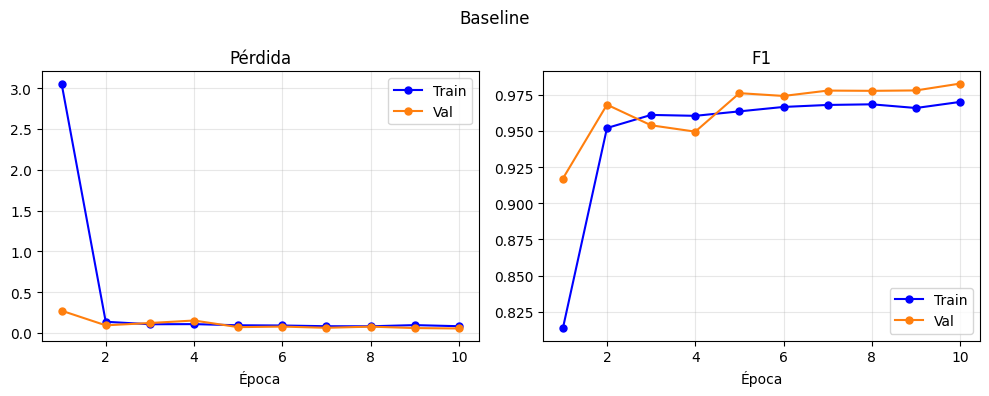

In [10]:
baseline_model = ChestXRayCNN().to(device)
baseline_history, baseline_best_f1 = train_model(
    baseline_model, train_loader, val_loader, epochs=BASELINE_EPOCHS, lr=1e-3
)
print(f"F1 val baseline: {baseline_best_f1:.4f}")
plot_history(baseline_history, "Baseline", "baseline_curves.png")


## 9. Random search


In [11]:
HP_GRID = {
    "base_filters": [16, 32],
    "kernel_size": [3, 5],
    "lr": [5e-4, 1e-3],
    "epochs": HP_TRIAL_EPOCHS,
    "dropout": [0.3, 0.5],
}
keys = list(HP_GRID.keys())
all_combos = list(itertools.product(*HP_GRID.values()))
search_combos = random.Random(SEED).sample(all_combos, min(N_RANDOM_TRIALS, len(all_combos)))
print(f"Trials: {len(search_combos)}")

search_results = []
for trial_id, combo in enumerate(search_combos, 1):
    hp = dict(zip(keys, combo))
    print(f"Trial {trial_id}: {hp}")
    m = ChestXRayCNN(
        base_filters=hp["base_filters"],
        kernel_size=hp["kernel_size"],
        dropout=hp["dropout"],
    ).to(device)
    _, best_f1 = train_model(m, train_loader, val_loader, hp["epochs"], hp["lr"], HP_TRIAL_PATIENCE)
    search_results.append({**hp, "trial": trial_id, "val_f1": best_f1})

results_df = pd.DataFrame(search_results).sort_values("val_f1", ascending=False)
display(results_df)
best_row = results_df.iloc[0]


Trials: 1
Trial 1: {'base_filters': 16, 'kernel_size': 3, 'lr': 0.001, 'epochs': 10, 'dropout': 0.5}


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

Época 1/10 | train f1=0.8677 | val f1=0.9456


  0%|          | 0/66 [00:00<?, ?it/s]

...

Época 9/10 | train f1=0.9750 | val f1=0.9199


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

Época 10/10 | train f1=0.9727 | val f1=0.9762


,base_filters,kernel_size,lr,epochs,dropout,trial,val_f1
0,16,3,0.001,10,0.5,1,0.980801


## 10. Modelo final y test


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

Época 1/10 | train f1=0.8536 | val f1=0.9510


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

...

  0%|          | 0/17 [00:00<?, ?it/s]

Época 9/10 | train f1=0.9715 | val f1=0.9788


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

Época 10/10 | train f1=0.9720 | val f1=0.9744
Early stopping


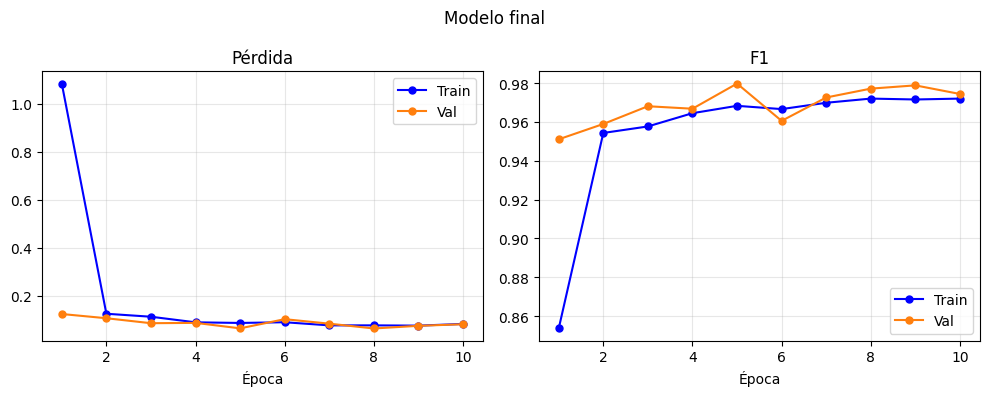

  0%|          | 0/10 [00:00<?, ?it/s]

Test — Acc: 0.7484 | F1: 0.7089
              precision    recall  f1-score   support

      NORMAL       0.96      0.34      0.50       234
   PNEUMONIA       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.67      0.67       624
weighted avg       0.81      0.75      0.71       624



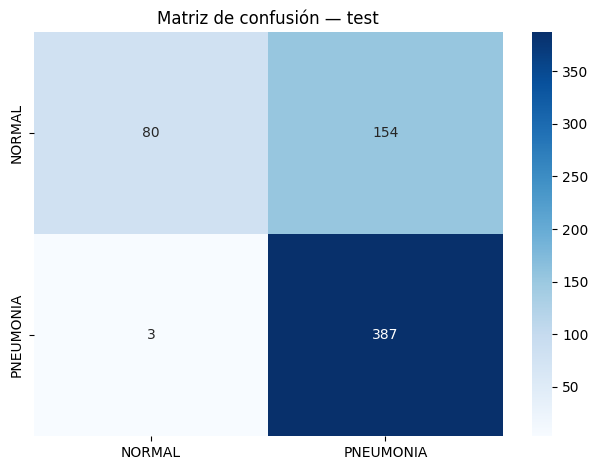

In [12]:
BEST_HP = {
    "base_filters": int(best_row["base_filters"]),
    "kernel_size": int(best_row["kernel_size"]),
    "dropout": float(best_row["dropout"]),
}
final_epochs = min(max(int(best_row["epochs"]), 5), FINAL_MAX_EPOCHS)
final_model = ChestXRayCNN(
    base_filters=BEST_HP["base_filters"],
    kernel_size=BEST_HP["kernel_size"],
    dropout=BEST_HP["dropout"],
).to(device)
final_history, _ = train_model(
    final_model, train_loader, val_loader, final_epochs, float(best_row["lr"]), patience=5
)
plot_history(final_history, "Modelo final", "final_curves.png")
torch.save(final_model.state_dict(), OUTPUT_DIR / "best_cnn_model.pth")

test_loss, test_m = run_epoch(final_model, test_loader, nn.CrossEntropyLoss(weight=class_weights.to(device)))
print(f"Test — Acc: {test_m['accuracy']:.4f} | F1: {test_m['f1']:.4f}")
print(classification_report(test_m["y_true"], test_m["y_pred"], target_names=CLASSES))
cm = confusion_matrix(test_m["y_true"], test_m["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Matriz de confusión — test")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_test.png", dpi=120)
plt.show()


## 11. Conclusiones

- Dataset Kaggle con desbalance de clases.
- CNN + regularización + pesos en la pérdida.
- Random search y evaluación final en test independiente.
- Resultados guardados en `outputs/`.
